<a href="https://colab.research.google.com/github/dhyun16/ESAA/blob/main/YB_1009(2)_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [2]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [16]:
# 전체 예측 데이터 중 실제값과 예측이 일치한 비율이다. 모델이 전체 데이터에 대해 얼마나 올바르게 예측했는지를 직관적으로 보여준다.
from sklearn.metrics import accuracy_score
print(accuracy_score(y, y_pred))

0.9121265377855887


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [17]:
# 모델이 양성(1, 악성)이라고 예측한 것 중 실제 양성인 비율이다. 위양성(False Positive, 양성이 아님에도 양성으로 잘못 예측)을 낮추는 것이 중요할 때 중요한 지표이다.
from sklearn.metrics import precision_score
print(precision_score(y,y_pred))

0.900990099009901


**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [18]:
# 실제 양성(1, 악성)인 것 중 모델이 양성으로 올바르게 예측한 비율이다. 위음성(False Negative, 실제 악성인데 양성/정상으로 잘못 예측)을 줄이는 것이 핵심일 때 사용한다
from sklearn.metrics import recall_score
print(recall_score(y,y_pred))

0.8584905660377359


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [19]:
# 정밀도와 재현율의 조화 평균이다.정밀도와 재현율 어느 한쪽으로 치우치지 않고 균형 잡힌 성능을 내고 있는지 평가할 수 있다.
from sklearn.metrics import f1_score
print(f1_score(y, y_pred))

0.8792270531400966


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [4]:
from sklearn.preprocessing import Binarizer

# 모델의 예측 확률 구하기 (열 0: 양성 확률, 열 1: 악성 확률)
y_pred_proba = model_lor.predict_proba(X)

# 예를 들어 악성(1)일 확률(y_pred_proba[:, 1])을 기준으로 임계값 적용
# 0으로 예측할 확률이 0.1보다 크다는 것은 악성일 확률이 0.9 미만이라는 의미일 수 있습니다.
# 여기서는 표준적인 확률 기반 Binarizer 활용 예시를 작성합니다.
prob_positive = y_pred_proba[:, 1] # 악성(1)일 확률

# 임계값 0.9 적용 (0으로 예측할 확률이 0.1 초과 -> 악성 확률이 0.9 미만인 경우 0, 이상인 경우 1)
threshold = 0.9
y_pred2 = (prob_positive >= threshold).astype(int)



In [6]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== y_pred2 평가 지표 ===")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred2))
print("Accuracy:", accuracy_score(y, y_pred2))
print("Precision:", precision_score(y, y_pred2, zero_division=0))
print("Recall:", recall_score(y, y_pred2, zero_division=0))
print("F1 Score:", f1_score(y, y_pred2, zero_division=0))

=== y_pred2 평가 지표 ===
Confusion Matrix:
 [[356   1]
 [ 73 139]]
Accuracy: 0.8699472759226714
Precision: 0.9928571428571429
Recall: 0.6556603773584906
F1 Score: 0.7897727272727273


**ROC 곡선 시각화**

In [7]:
from sklearn.metrics import roc_curve


In [8]:
import matplotlib.pyplot as plt


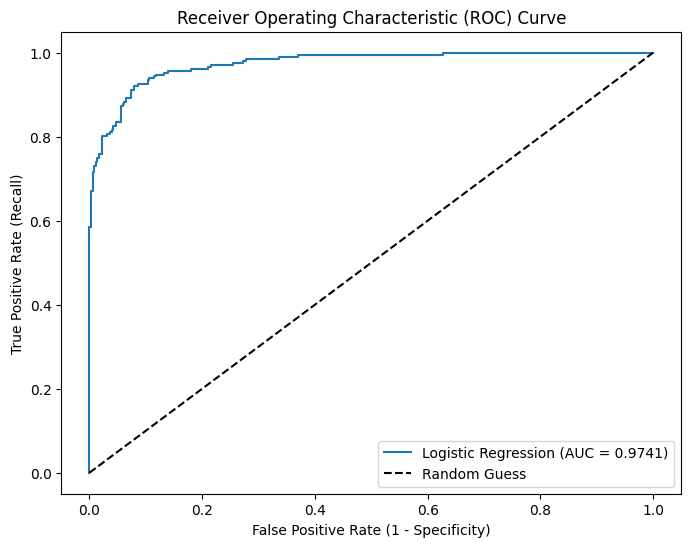

In [13]:
from sklearn.metrics import roc_auc_score

# ROC 곡선 계산
fpr, tpr, thresholds = roc_curve(y, y_pred_proba[:, 1])

# ROC 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [15]:
# ROC AUC 값 계산
roc_auc = roc_auc_score(y, y_pred_proba[:, 1])
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.974076423022039


모든 임계값 상에서 모델의 전반적인 분류 성능을 나타낸다.값이 1에 가까울수록 모델이 양성과 음성을 구분하는 변별력이 완벽함을 뜻한다.